In [ ]:
import torch
TORCH_VERSION = ".".join(torch.__version__.split(".")[:2])
print("torch:", TORCH_VERSION, ";cuda:", torch.version.cuda)
!python -m pip install 'git+https://github.com/facebookresearch/detectron2.git'


In [2]:
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()
import numpy as np
import os,json,cv2,random
from google.colab.patches import cv2_imshow
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog,DatasetCatalog

In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="s7aXbRH11TJRFmVscMWd")
project = rf.workspace("ankitagrawaljhansi1-gmail-com").project("machine-learning-zmku6")
version = project.version(2)
dataset = version.download("coco")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
!curl -L "https://app.roboflow.com/ds/1opba2ctaj?key=TQDClATMjC" > roboflow.zip; unzip -o roboflow.zip; rm roboflow.zip


In [5]:
from detectron2.data.datasets import register_coco_instances
register_coco_instances("my_dataset_train",{},"/content/train/_annotations.coco.json","/content/train")
register_coco_instances("my_dataset_test",{},"/content/test/_annotations.coco.json","/content/test")

WARNING [07/15 14:28:30 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[07/15 14:28:30 d2.data.datasets.coco]: Loaded 79 images in COCO format from /content/train/_annotations.coco.json


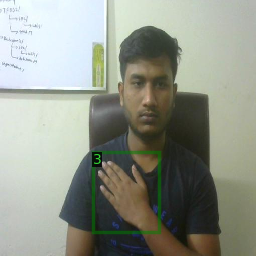

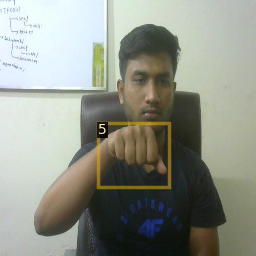

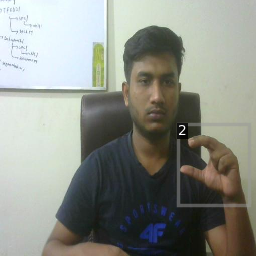

In [6]:
my_dataset_train_metadata=MetadataCatalog.get("my_dataset_train")
dataset_dicts=DatasetCatalog.get("my_dataset_train")
import random
from detectron2.utils.visualizer import Visualizer
for d in random.sample(dataset_dicts,3):
  img=cv2.imread(d["file_name"])
  visualizer=Visualizer(img[:,:,::-1],metadata=my_dataset_train_metadata,scale=0.5)
  vis=visualizer.draw_dataset_dict(d)
  cv2_imshow(vis.get_image()[:,:,::-1])

In [ ]:
from detectron2.engine import DefaultTrainer

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("my_dataset_train",)
cfg.DATASETS.TEST = ()
cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")  # Let training initialize from model zoo
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.0025  # pick a good LR
cfg.SOLVER.MAX_ITER = 500    # 300 iterations seems good enough for this toy dataset; you will need to train longer for a practical dataset
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128   # faster, and good enough for this toy dataset (default: 512)
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 6  # (see https://detectron2.readthedocs.io/tutorials/datasets.html#update-the-config-for-new-datasets)
# NOTE: this config means the number of classes, but a few popular unofficial tutorials incorrectly uses num_classes+1

cfg.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"  # use the T4 GPU when available

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=True)
trainer.train()

In [ ]:
%load_ext tensorboard
%tensorboard --logdir output

In [ ]:
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5   # set the testing threshold for this model
cfg.DATASETS.TEST = ("my_dataset_test", )
predictor = DefaultPredictor(cfg)

In [ ]:
test_metadata = MetadataCatalog.get("my_dataset_test")

In [ ]:
from detectron2.utils.visualizer import ColorMode
import glob

for imageName in glob.glob('/content/test/*jpg'):
    im = cv2.imread(imageName)
    outputs = predictor(im)
    v = Visualizer(im[:, :, ::-1],
                    metadata=test_metadata,
                    scale=0.8,
                    instance_mode=ColorMode.IMAGE_SEGMENTATION
                    )
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
    cv2_imshow(out.get_image()[:, :, ::-1])

In [ ]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader

evaluator = COCOEvaluator("my_dataset_test", output_dir="./output")
val_loader = build_detection_test_loader(cfg, "my_dataset_test")
print(inference_on_dataset(predictor.model, val_loader, evaluator))

In [ ]:
f = open('config.yml', 'w')
f.write(cfg.dump())
f.close()